# 종합 리포트(채점 엔진) 평가 리포트 — 시각화 자료

> 작성: 경이 / 2026-07-29  
> 본문: [종합리포트_평가리포트_20260729_mky.md](종합리포트_평가리포트_20260729_mky.md)  
> 모든 수치는 실측값 — 서버 곡선은 배포 환경(2026-07-29), 문서 특성·상한은 `scripts/eval_report_signals_mky.py`(LLM 호출 없는 결정론 재계산).

그림은 `2026_07_29_시각화자료_mky/`에 PNG로도 저장된다 (발표 자료용).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 폰트 (Windows)
plt.rcParams["axes.unicode_minus"] = False

# ── 실측 데이터 (출처: docs/evaluation/종합리포트_평가리포트_20260729_mky.md) ──
# 배포 서버 최종 곡선(2026-07-29)과 scripts/eval_report_signals_mky.py 결정론 실측.
VERSIONS = ["v1.0", "v1.1", "v1.2", "v1.3"]
FINAL  = [29.5, 67, 65, 73]      # After — 상향 변별 적용 (실험 9)
BEFORE = [29.5, 65, 65, 65]      # Before — 하향 규칙만 (65 앵커링)
CHARS = [1202, 3236, 5025, 10688]  # 글자수(공백 제외)
ORGS  = [0, 4, 1, 5]               # 실명 기관 수
QUANT = [5, 14, 51, 164]           # 정량 표현 수
CRITS = ["목표 부합성\n(15점)", "기술성·혁신성\n(30점)", "실현 가능성\n(30점)", "확산성·효과성\n(10점)"]
MAXES = [15, 30, 30, 10]
CAPS  = [6.0, 12.0, 7.5, 4.0]      # v1.0 상한 — 합계 29.5 = 서버 총점
SIGNALS = ["S6", "S6", "S6+S2+S4\n+MULTI", "S6+S2"]

PURPLE, GRAY, CORAL, GREEN = "#7c5cea", "#b9b3cc", "#e2574c", "#3a9e6e"

## 그림 1 — 변별력: 버전 시리즈 최종 곡선
품질 조작 테스트셋(v1.0 부실 → v1.3 완성)의 의도 순위를 점수가 재현하는지. 격차가 큰 구간(v1.0, v1.3)은 안정 분리, 작은 구간(v1.1↔v1.2)은 LLM 분산(±2)에 묻힌다.

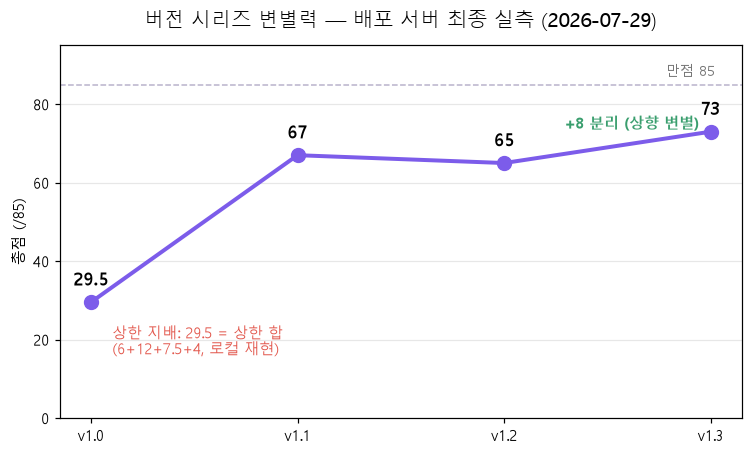

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(VERSIONS, FINAL, marker="o", markersize=9, linewidth=2.6, color=PURPLE, zorder=3)
for x, y in zip(VERSIONS, FINAL):
    ax.annotate(f"{y:g}", (x, y), textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=12, fontweight="bold")
ax.annotate("상한 지배: 29.5 = 상한 합\n(6+12+7.5+4, 로컬 재현)", ("v1.0", 29.5),
            textcoords="offset points", xytext=(14, -34), fontsize=9.5, color=CORAL)
ax.annotate("+8 분리 (상향 변별)", ("v1.3", 73), textcoords="offset points",
            xytext=(-96, 2), fontsize=10, color=GREEN, fontweight="bold")
ax.axhline(85, color=GRAY, linestyle="--", linewidth=1)
ax.text(3.02, 86.5, "만점 85", va="bottom", ha="right", fontsize=9, color="#777")
ax.set_ylim(0, 95)
ax.set_ylabel("총점 (/85)")
ax.set_title("버전 시리즈 변별력 — 배포 서버 최종 실측 (2026-07-29)", fontsize=13, pad=12)
ax.grid(axis="y", alpha=0.3)
fig.savefig("2026_07_29_시각화자료_mky/fig1_최종곡선.png", dpi=150, bbox_inches="tight")
plt.show()

## 그림 2 — 개선 실험 9: 65점 앵커링 수리 (Before/After)
하향 규칙만 있던 위원 프롬프트에서 서로 다른 문서 4개가 전부 65로 수렴(라운드 넘버 앵커링). [상향 변별] 규칙(실명 출처·정량 실적·완료형 실행+검증·차별성 비교, 3요건+ → strong 강제) 추가 후 완성 문서만 +8 분리 — 부실 문서는 상한이 그대로 잡아 하한 안전망 확인.

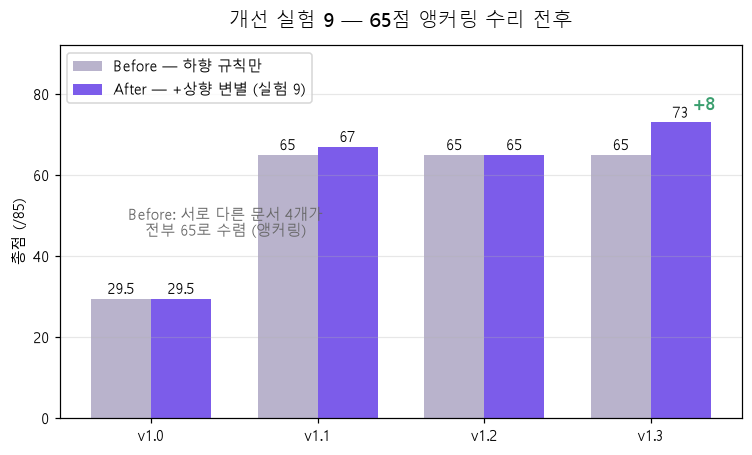

In [ ]:
x = np.arange(len(VERSIONS))
w = 0.36
fig, ax = plt.subplots(figsize=(8, 4.4))
b1 = ax.bar(x - w / 2, BEFORE, w, label="Before — 하향 규칙만", color=GRAY)
b2 = ax.bar(x + w / 2, FINAL, w, label="After — +상향 변별 (실험 9)", color=PURPLE)
for bars in (b1, b2):
    for rect in bars:
        ax.annotate(f"{rect.get_height():g}", (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                    textcoords="offset points", xytext=(0, 3), ha="center", fontsize=10)
ax.annotate("Before: 서로 다른 문서 4개가\n전부 65로 수렴 (앵커링)", (0.45, 45), fontsize=9.5, color="#666", ha="center")
ax.annotate("+8", (3 + w / 2, 73), textcoords="offset points", xytext=(15, 8),
            ha="center", fontsize=12, fontweight="bold", color=GREEN)
ax.set_xticks(x, VERSIONS)
ax.set_ylim(0, 92)
ax.set_ylabel("총점 (/85)")
ax.set_title("개선 실험 9 — 65점 앵커링 수리 전후", fontsize=13, pad=12)
ax.legend(loc="upper left", fontsize=9.5)
ax.grid(axis="y", alpha=0.3)
fig.savefig("2026_07_29_시각화자료_mky/fig2_앵커링_전후.png", dpi=150, bbox_inches="tight")
plt.show()

## 그림 3 — 재현성: v1.0 상한 발동 내역
부실 문서의 총점 29.5는 결정론 상한 합(6+12+7.5+4)과 정확히 일치 — LLM 없이 로컬에서 재현된다. 신호: S2 정량 없음 / S4 실행 실체 없음 / S6 분량 깊이 부족 / MULTI 복합 결핍.

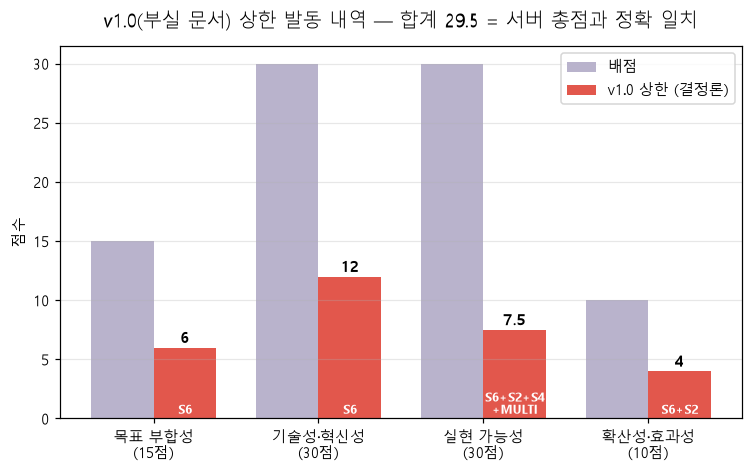

In [ ]:
x = np.arange(len(CRITS))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(x - w / 2, MAXES, w, label="배점", color=GRAY)
bars = ax.bar(x + w / 2, CAPS, w, label="v1.0 상한 (결정론)", color=CORAL)
for rect, sig, cap in zip(bars, SIGNALS, CAPS):
    ax.annotate(f"{cap:g}", (rect.get_x() + rect.get_width() / 2, cap),
                textcoords="offset points", xytext=(0, 3), ha="center", fontsize=10, fontweight="bold")
    ax.annotate(sig, (rect.get_x() + rect.get_width() / 2, 0.4), ha="center",
                fontsize=8, color="white", fontweight="bold")
ax.set_xticks(x, CRITS, fontsize=9.5)
ax.set_ylabel("점수")
ax.set_title("v1.0(부실 문서) 상한 발동 내역 — 합계 29.5 = 서버 총점과 정확 일치", fontsize=12.5, pad=12)
ax.legend(fontsize=9.5)
ax.grid(axis="y", alpha=0.3)
fig.savefig("2026_07_29_시각화자료_mky/fig3_v10_상한내역.png", dpi=150, bbox_inches="tight")
plt.show()

## 그림 4 — 테스트셋 특성 (결정론 실측)
품질 조작이 실제로 단계적임을 채점 엔진과 동일한 함수로 증명 — 글자수·실명 기관·정량 표현이 버전에 따라 증가한다. v1.3의 실명 기관 5·정량 표현 164가 상향 변별 4요건 충족의 근거.

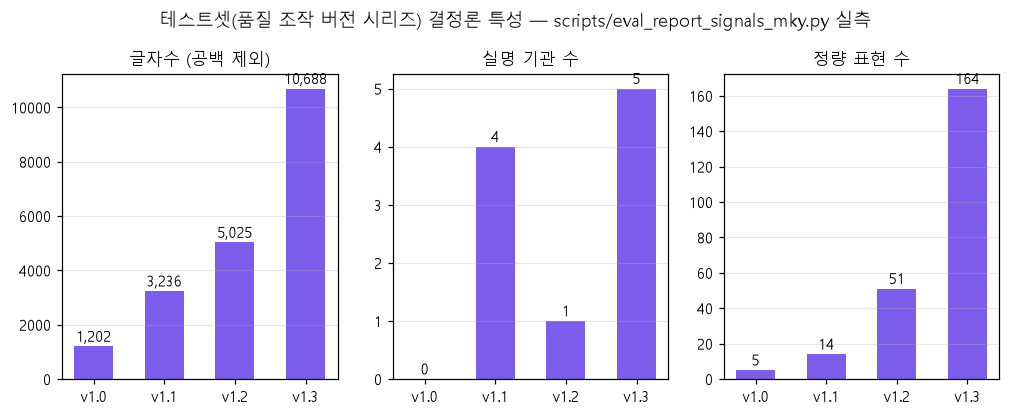

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, data, title in zip(
    axes, [CHARS, ORGS, QUANT], ["글자수 (공백 제외)", "실명 기관 수", "정량 표현 수"]
):
    bars = ax.bar(VERSIONS, data, color=PURPLE, width=0.55)
    for rect in bars:
        ax.annotate(f"{rect.get_height():,}", (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                    textcoords="offset points", xytext=(0, 3), ha="center", fontsize=9.5)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("테스트셋(품질 조작 버전 시리즈) 결정론 특성 — scripts/eval_report_signals_mky.py 실측", fontsize=12, y=1.04)
fig.savefig("2026_07_29_시각화자료_mky/fig4_테스트셋특성.png", dpi=150, bbox_inches="tight")
plt.show()

## 그림 5 — Rubric 자동 추출·측정성 스코핑 (기준 충실성)
공고문 배점표 100점을 LLM으로 추출하되 3중 검증(배점 합계 서버 재계산 · perspective 화이트리스트 · 항목별 위원 배정 강제)으로 rubric 지어내기를 차단하고, 문서만으로 측정 불가한 항목(안전성·윤리성 — 가치 판단, 가점 — 공모전별 변동·증빙 필요)은 **점수에서 제외하되 사유를 점수 체계표에 명시**한다. 추출 결과는 프로젝트별 캐시(버전 v9)로 관리 — 같은 공고문이면 같은 rubric. 관련 실험: 실험 3(기준 충실성 위반 0건) · 실험 5(주관성 배제).

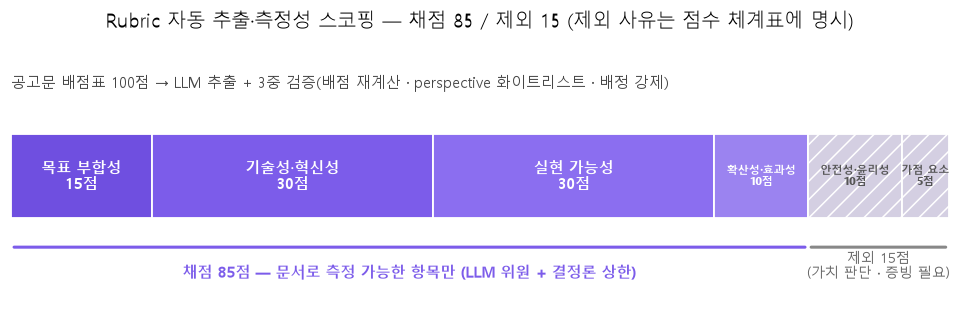

In [ ]:
segments = [
    ("목표 부합성", 15, "채점"), ("기술성·혁신성", 30, "채점"),
    ("실현 가능성", 30, "채점"), ("확산성·효과성", 10, "채점"),
    ("안전성·윤리성", 10, "제외"), ("가점 요소", 5, "제외"),
]
scored_colors = ["#6f4fe0", "#7c5cea", "#8b6ef0", "#9b83f0"]
fig, ax = plt.subplots(figsize=(11, 3.2))
left, si = 0, 0
for name, pts, kind in segments:
    if kind == "채점":
        color, hatch, tcolor = scored_colors[si], None, "white"
        si += 1
    else:
        color, hatch, tcolor = "#d4cfe2", "//", "#555"
    ax.barh(0, pts, left=left, height=0.5, color=color, hatch=hatch,
            edgecolor="white", linewidth=1.2)
    ax.text(left + pts / 2, 0, f"{name}\n{pts}점", ha="center", va="center",
            fontsize=9.5 if pts >= 15 else 7.2, color=tcolor, fontweight="bold")
    left += pts
ax.annotate("", xy=(0, -0.42), xytext=(85, -0.42),
            arrowprops=dict(arrowstyle="-", color=PURPLE, linewidth=2))
ax.text(42.5, -0.6, "채점 85점 — 문서로 측정 가능한 항목만 (LLM 위원 + 결정론 상한)",
        ha="center", fontsize=10, color=PURPLE, fontweight="bold")
ax.annotate("", xy=(85, -0.42), xytext=(100, -0.42),
            arrowprops=dict(arrowstyle="-", color="#888", linewidth=2))
ax.text(92.5, -0.6, "제외 15점\n(가치 판단 · 증빙 필요)", ha="center", fontsize=9, color="#666")
ax.text(0, 0.52, "공고문 배점표 100점 → LLM 추출 + 3중 검증(배점 재계산 · perspective 화이트리스트 · 배정 강제)",
        fontsize=9.5, color="#444")
ax.set_xlim(0, 100)
ax.set_ylim(-0.85, 0.75)
ax.axis("off")
ax.set_title("Rubric 자동 추출·측정성 스코핑 — 채점 85 / 제외 15 (제외 사유는 점수 체계표에 명시)",
             fontsize=12.5, pad=14)
fig.savefig("2026_07_29_시각화자료_mky/fig5_rubric_스코핑.png", dpi=150, bbox_inches="tight")
plt.show()

## 해석 요약 (발표용)
1. **하한 신뢰성은 결정론이 보장** — 부실 문서 29.5는 상한 합으로 고정, 로컬 재현 가능 (그림 3)
2. **상향 변별은 프롬프트 규칙으로 개방** — 4요건 충족 문서만 +8 분리, 하한 유지 (그림 2)
3. **테스트셋은 골든셋** — 의도 품질 순위가 정답 라벨, 특성은 결정론 실측으로 증명 (그림 4)
4. **채점의 잣대(Rubric)도 검증 대상** — LLM 추출 + 3중 검증으로 기준 지어내기 차단, 측정 불가 항목은 사유와 함께 제외 (그림 5)
5. **한계** — 미세 품질 차(v1.1↔v1.2)는 LLM 분산에 묻힘 → TST-002 반복 편차 실측이 다음 단계